# Phase 1.5 v3 — Optuna GridSampler 로 Walk-Forward 가설 검증 (`02_v3_lstm_optuna.ipynb`)

> **목적**: v1, v2 의 LSTM 부적합 결론 더 깊이 검증.
> 3 가설을 동시에 grid search 로 직접 비교.

## 검증 가설

| 가설 | 변수 | 후보값 |
|---|---|---|
| (a) 변수 부족 | `input_channels` | `'1ch'`, `'3ch'` |
| (a) + (c) 샘플·체제 | `is_len` | `252`, `504`, `750` |
| (b) Long-memory 잔존 | `embargo` | `63`, `126` |

**총 unique 조합: 2 × 3 × 2 = 12**

## 고정 (v1 결과 그대로 — 비교 공정성)

```python
hidden_size  = 32
dropout      = 0.3
lr           = 1e-3
weight_decay = 1e-3
max_epochs   = 30
patience     = 5
batch_size   = 32
seed         = 42
```

## Optuna 설정

- **Sampler**: `GridSampler` (12 조합 정확히 1회씩)
- **Direction**: minimize
- **Objective**: `(SPY RMSE + QQQ RMSE) / 2` — 90 fold OOS 평균
- **Trials**: 12 (모든 조합 cover)

## 사용자 GPU 환경 가이드

### 1. Optuna 설치 (1회)
```bash
pip install optuna
```

### 2. 실행 흐름
- 본 노트북을 `Run All` (~10~15분 예상)
- 12 trials 의 RMSE 비교 표 출력
- HAR / EWMA / Naive 와 직접 비교

### 3. 산출물
```
results/lstm_optuna/
├── all_trials.csv              (12 trials 전체 결과)
├── best_metrics.json            (최적 조합 metrics)
└── lstm_optuna_summary.md       (자동 생성 보고서)
```

## 본 노트북 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + GPU 감지 + Optuna import |
| §2 | 데이터 로드 + 입력 채널 사전 준비 (1ch + HAR 3ch) |
| §3 | LSTM 학습 함수 정의 — `run_lstm_for_config` |
| §4 | Optuna Objective + GridSampler study |
| §5 | 12 trials 비교 표 + 최적 조합 |
| §6 | HAR / EWMA / Naive 와 RMSE 비교 (관문 1 재판정) |
| §7 | 결론 + `lstm_optuna_summary.md` 자동 생성 |


## §1. 환경 부트스트랩 + GPU 감지 + Optuna import

### Optuna 설치 안내

본 노트북 첫 실행 전 **터미널에서 1회**:
```bash
pip install optuna
```


In [1]:
# 환경 부트스트랩
import sys
import json
import time
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

from scripts.setup import bootstrap, BASE_DIR, RAW_DATA_DIR, RESULTS_DIR
font_used = bootstrap()

# Optuna import (미설치 시 안내)
try:
    import optuna
    print(f'optuna {optuna.__version__} 로드 완료')
except ImportError:
    print('[ERROR] optuna 미설치. 터미널에서 다음을 1회 실행:')
    print('  pip install optuna')
    raise

# GPU 자동 감지
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  CUDA: {torch.version.cuda}')

print(f'\nBASE_DIR     = {BASE_DIR}')
print(f'RESULTS_DIR  = {RESULTS_DIR}')


  Phase 1 — 환경 부트스트랩 완료
  한글 폰트  : Malgun Gothic
  시드       : 42
  결과 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results
optuna 4.8.0 로드 완료
사용 device: cuda
  GPU: NVIDIA GeForce RTX 4090
  CUDA: 12.6

BASE_DIR     = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
RESULTS_DIR  = C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results


## §2. 데이터 로드 + 입력 채널 사전 준비

`run_lstm_for_config` 가 매 trial 마다 사용하므로 미리 준비:
- **1ch (v1 동일)**: `log_ret²` (instantaneous variance proxy)
- **3ch (v2 동일)**: HAR `[|log_ret|, RV_w, RV_m]` (Corsi 2009 표준)
- **target**: `target_logrv` (forward 21일 log RV, v1·v2 동일)


In [2]:
import pandas as pd
import numpy as np
from scripts.targets_volatility import build_daily_target_logrv_21d

ANALYSIS_START = '2016-01-01'
ANALYSIS_END   = '2025-12-31'
WINDOW = 21
SEQ_LEN = 63
HAR_W_WINDOW = 5
HAR_M_WINDOW = 22


def load_ticker_full(ticker: str) -> pd.DataFrame:
    csv_path = RAW_DATA_DIR / f'{ticker}.csv'
    df = pd.read_csv(csv_path, index_col=0, parse_dates=True).sort_index()
    df['log_ret'] = np.log(df['Adj Close']).diff()
    return df


# 분석 기간 절단 + 입력 채널 사전 준비
analysis_dict = {}
for tk in ('SPY', 'QQQ'):
    raw = load_ticker_full(tk)
    df = raw.loc[ANALYSIS_START:ANALYSIS_END].copy()
    # 1ch 입력 (v1 동일)
    df['log_ret_sq'] = df['log_ret'] ** 2
    # 3ch HAR 입력 (v2 동일)
    df['rv_d'] = df['log_ret'].abs()
    df['rv_w'] = (df['log_ret'] ** 2).rolling(HAR_W_WINDOW).mean().pow(0.5)
    df['rv_m'] = (df['log_ret'] ** 2).rolling(HAR_M_WINDOW).mean().pow(0.5)
    # 타깃
    df['target_logrv'] = build_daily_target_logrv_21d(df['Adj Close'], window=WINDOW)
    analysis_dict[tk] = df
    n = len(df)
    n_target = int(df['target_logrv'].notna().sum())
    print(f'{tk}: n={n} (시작 {df.index[0].date()}), 유효 target={n_target}')

# 유효 타깃 수 (모든 IS 에서 동일)
N_VALID = min(int(analysis_dict[tk]['target_logrv'].notna().sum()) for tk in ('SPY', 'QQQ'))
print(f'\nN_VALID (min over SPY/QQQ): {N_VALID}')


SPY: n=2514 (시작 2016-01-04), 유효 target=2493
QQQ: n=2514 (시작 2016-01-04), 유효 target=2493

N_VALID (min over SPY/QQQ): 2493


## §3. LSTM 학습 함수 — `run_lstm_for_config`

각 trial 의 (input_channels, is_len, embargo) 조합에 대해:
1. Walk-Forward fold 생성 (is_len, embargo 동적)
2. 입력 채널 분기 (1ch 또는 3ch)
3. 90 fold (또는 그에 상응하는 fold 수) 학습 + OOS 예측
4. SPY/QQQ 평균 RMSE 반환

**주의**: GPU 환경에서 `device='cuda'` 자동 사용.


In [3]:
from torch.utils.data import TensorDataset, DataLoader
from scripts.dataset import build_fold_datasets, walk_forward_folds
from scripts.models import LSTMRegressor
from scripts.train import train_one_fold

# 고정 hyperparameter (v1 동일)
HIDDEN = 32
NUM_LAYERS = 1
DROPOUT = 0.3
LR = 1e-3
WEIGHT_DECAY = 1e-3
MAX_EPOCHS = 30
PATIENCE = 5
LR_PATIENCE = 3
LOSS_TYPE = 'mse'
BATCH_SIZE = 32
VAL_RATIO = 0.2
SEED = 42

# Walk-Forward 고정값
PURGE = 21
OOS_LEN = 21
STEP = 21


def build_input_arrays(df: pd.DataFrame, input_channels: str):
    """입력 채널 분기. 반환: (series_1d, extra_features_2d_or_None)."""
    if input_channels == '1ch':
        series = df['log_ret_sq'].fillna(0.0).values
        extra = None
    elif input_channels == '3ch':
        series = df['rv_d'].fillna(0.0).values
        extra = np.column_stack([
            df['rv_w'].fillna(0.0).values,
            df['rv_m'].fillna(0.0).values,
        ])
    else:
        raise ValueError(f'알 수 없는 input_channels: {input_channels}')
    return series, extra


def build_train_val_loaders(train_ds, val_ratio=VAL_RATIO, batch_size=BATCH_SIZE):
    n = len(train_ds)
    n_val = max(1, int(n * val_ratio))
    n_tr = n - n_val
    train_sub = TensorDataset(train_ds.X[:n_tr], train_ds.y[:n_tr])
    val_sub   = TensorDataset(train_ds.X[n_tr:], train_ds.y[n_tr:])
    tr_loader = DataLoader(train_sub, batch_size=batch_size, shuffle=True)
    va_loader = DataLoader(val_sub, batch_size=max(1, n_val), shuffle=False)
    return tr_loader, va_loader


def run_lstm_single_ticker(
    ticker: str, df: pd.DataFrame,
    input_channels: str, is_len: int, embargo: int,
    log_progress: bool = False,
):
    """단일 ticker 의 모든 fold 학습 + 평균 RMSE 반환."""
    series, extra = build_input_arrays(df, input_channels)
    target = df['target_logrv'].values
    input_size = 1 if input_channels == '1ch' else 3

    folds = walk_forward_folds(
        n=N_VALID, is_len=is_len, purge=PURGE, emb=embargo,
        oos_len=OOS_LEN, step=STEP,
    )
    n_folds = len(folds)

    # seed 재고정 (재현성)
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if device.type == 'cuda':
        torch.cuda.manual_seed_all(SEED)

    rmse_per_fold = []
    t_start = time.time()
    for k, (tr_idx, te_idx) in enumerate(folds):
        tr_ds_k, te_ds_k, _ = build_fold_datasets(
            series=series, train_idx=tr_idx, test_idx=te_idx,
            seq_len=SEQ_LEN, extra_features=extra, target_series=target,
        )
        tr_loader, va_loader = build_train_val_loaders(tr_ds_k)
        model_k = LSTMRegressor(
            input_size=input_size, hidden_size=HIDDEN,
            num_layers=NUM_LAYERS, dropout=DROPOUT, batch_first=True,
        )
        result = train_one_fold(
            model_k, tr_loader, va_loader,
            max_epochs=MAX_EPOCHS, early_stop_patience=PATIENCE,
            lr=LR, weight_decay=WEIGHT_DECAY, lr_patience=LR_PATIENCE,
            loss_type=LOSS_TYPE, device=device, verbose=False,
        )
        # best 로 OOS 예측
        model_k.load_state_dict(result['best_state_dict'])
        model_k.to(device).eval()
        with torch.no_grad():
            y_pred = model_k(te_ds_k.X.to(device)).cpu().numpy().flatten()
        y_true = te_ds_k.y.numpy()
        rmse_k = float(np.sqrt(((y_true - y_pred) ** 2).mean()))
        rmse_per_fold.append(rmse_k)

        if device.type == 'cuda':
            torch.cuda.empty_cache()

    elapsed = time.time() - t_start
    rmse_mean = float(np.mean(rmse_per_fold))
    rmse_std  = float(np.std(rmse_per_fold, ddof=1))
    if log_progress:
        print(f'    [{ticker}] {input_channels}/IS={is_len}/emb={embargo} | '
              f'fold={n_folds} RMSE={rmse_mean:.4f}±{rmse_std:.4f} | {elapsed:.0f}s')
    return {
        'rmse_mean': rmse_mean, 'rmse_std': rmse_std,
        'n_folds': n_folds, 'rmse_per_fold': rmse_per_fold,
        'elapsed_sec': elapsed,
    }


def run_lstm_for_config(input_channels: str, is_len: int, embargo: int,
                          log_progress: bool = True) -> dict:
    """SPY/QQQ 두 종목 학습 후 평균 RMSE 반환 (Optuna objective 호출 함수)."""
    out = {}
    for tk in ('SPY', 'QQQ'):
        out[tk] = run_lstm_single_ticker(
            tk, analysis_dict[tk],
            input_channels=input_channels, is_len=is_len, embargo=embargo,
            log_progress=log_progress,
        )
    avg_rmse = (out['SPY']['rmse_mean'] + out['QQQ']['rmse_mean']) / 2
    return {
        'avg_rmse': avg_rmse,
        'spy': out['SPY'], 'qqq': out['QQQ'],
        'n_folds': out['SPY']['n_folds'],
    }


print('학습 함수 정의 완료. Optuna trial 시 호출 가능.')
print(f'  - run_lstm_for_config(input_channels, is_len, embargo) → dict')


학습 함수 정의 완료. Optuna trial 시 호출 가능.
  - run_lstm_for_config(input_channels, is_len, embargo) → dict


## §4. Optuna Objective + GridSampler study (12 trials)

### GridSampler 의 의미
> 12 unique 조합을 정확히 1번씩 시도. TPE 보다 효율적 (categorical only 환경).

### 진행률 출력
각 trial 마다:
- (input_channels, is_len, embargo) 조합
- SPY/QQQ 각각의 RMSE
- 평균 RMSE


In [4]:
# Search Space
search_space = {
    'input_channels': ['1ch', '3ch'],
    'is_len':         [252, 504, 750],
    'embargo':        [63, 126],
}
n_combos = 1
for v in search_space.values():
    n_combos *= len(v)
print(f'Search space: {search_space}')
print(f'총 조합 수: {n_combos}')


# 결과 저장 폴더
OPTUNA_DIR = RESULTS_DIR / 'lstm_optuna'
OPTUNA_DIR.mkdir(parents=True, exist_ok=True)


# Trial 결과 누적 (callback 으로 저장)
trial_records = []


def objective(trial):
    input_channels = trial.suggest_categorical('input_channels', search_space['input_channels'])
    is_len         = trial.suggest_categorical('is_len',         search_space['is_len'])
    embargo        = trial.suggest_categorical('embargo',        search_space['embargo'])

    print(f'\n[Trial {trial.number+1}/{n_combos}] '
          f'input={input_channels}, IS={is_len}, embargo={embargo}')

    result = run_lstm_for_config(
        input_channels=input_channels, is_len=is_len, embargo=embargo,
        log_progress=True,
    )

    record = {
        'trial': trial.number,
        'input_channels': input_channels,
        'is_len': is_len,
        'embargo': embargo,
        'n_folds': result['n_folds'],
        'spy_rmse': result['spy']['rmse_mean'],
        'spy_rmse_std': result['spy']['rmse_std'],
        'qqq_rmse': result['qqq']['rmse_mean'],
        'qqq_rmse_std': result['qqq']['rmse_std'],
        'avg_rmse': result['avg_rmse'],
        'elapsed_sec': result['spy']['elapsed_sec'] + result['qqq']['elapsed_sec'],
    }
    trial_records.append(record)
    print(f'  → 평균 RMSE = {result["avg_rmse"]:.4f}')

    return result['avg_rmse']


# Optuna study (GridSampler)
sampler = optuna.samplers.GridSampler(search_space, seed=SEED)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler,
    study_name='lstm_v3_gridsearch',
)

# 실행
print(f'\n{"=" * 80}')
print(f'Optuna GridSampler 실행 시작 — 12 trials')
print(f'{"=" * 80}')
t_total_start = time.time()
study.optimize(objective, n_trials=n_combos)
t_total_elapsed = time.time() - t_total_start

print(f'\n{"=" * 80}')
print(f'Optuna GridSampler 완료 — 총 시간 {t_total_elapsed/60:.1f}분')
print(f'{"=" * 80}')


[I 2026-04-27 13:54:06,487] A new study created in memory with name: lstm_v3_gridsearch


Search space: {'input_channels': ['1ch', '3ch'], 'is_len': [252, 504, 750], 'embargo': [63, 126]}
총 조합 수: 12

Optuna GridSampler 실행 시작 — 12 trials

[Trial 1/12] input=3ch, IS=504, embargo=126
    [SPY] 3ch/IS=504/emb=126 | fold=87 RMSE=0.5989±0.7135 | 50s


[I 2026-04-27 13:55:47,714] Trial 0 finished with value: 0.5857236611003849 and parameters: {'input_channels': '3ch', 'is_len': 504, 'embargo': 126}. Best is trial 0 with value: 0.5857236611003849.


    [QQQ] 3ch/IS=504/emb=126 | fold=87 RMSE=0.5726±0.7409 | 51s
  → 평균 RMSE = 0.5857

[Trial 2/12] input=3ch, IS=252, embargo=126
    [SPY] 3ch/IS=252/emb=126 | fold=99 RMSE=0.8433±1.1587 | 43s


[I 2026-04-27 13:57:11,995] Trial 1 finished with value: 0.7413532433636261 and parameters: {'input_channels': '3ch', 'is_len': 252, 'embargo': 126}. Best is trial 0 with value: 0.5857236611003849.


...

    [QQQ] 1ch/IS=504/emb=126 | fold=87 RMSE=0.4559±0.2970 | 48s
  → 평균 RMSE = 0.4704

[Trial 11/12] input=3ch, IS=252, embargo=63
    [SPY] 3ch/IS=252/emb=63 | fold=102 RMSE=0.7933±1.0583 | 42s


[I 2026-04-27 14:12:34,004] Trial 10 finished with value: 0.7146283726700965 and parameters: {'input_channels': '3ch', 'is_len': 252, 'embargo': 63}. Best is trial 4 with value: 0.40011685714125633.


    [QQQ] 3ch/IS=252/emb=63 | fold=102 RMSE=0.6360±0.8387 | 41s
  → 평균 RMSE = 0.7146

[Trial 12/12] input=1ch, IS=252, embargo=126
    [SPY] 1ch/IS=252/emb=126 | fold=99 RMSE=0.5070±0.3313 | 39s


[I 2026-04-27 14:13:50,711] Trial 11 finished with value: 0.4968942879426359 and parameters: {'input_channels': '1ch', 'is_len': 252, 'embargo': 126}. Best is trial 4 with value: 0.40011685714125633.


    [QQQ] 1ch/IS=252/emb=126 | fold=99 RMSE=0.4868±0.3125 | 38s
  → 평균 RMSE = 0.4969

Optuna GridSampler 완료 — 총 시간 19.7분


## §5. 12 trials 비교 표 + 최적 조합

### 출력
1. 12 trials 정렬된 표 (avg_rmse 오름차순)
2. 최적 trial 의 (input_channels, is_len, embargo) 조합
3. v1, v2 baseline 과 비교 (1ch + IS=504 + embargo=63 = v1)


In [5]:
# Trial 결과를 DataFrame 으로 정리
df_trials = pd.DataFrame(trial_records).sort_values('avg_rmse').reset_index(drop=True)

# CSV 저장
csv_path = OPTUNA_DIR / 'all_trials.csv'
df_trials.to_csv(csv_path, index=False)
print(f'저장: {csv_path}')

# 출력 표
print()
print('=' * 100)
print('Optuna GridSearch 12 trials 결과 (avg_rmse 오름차순)')
print('=' * 100)
print(f'  {"rank":<5} {"input":<6} {"IS":<5} {"emb":<5} {"folds":<6} '
      f'{"SPY RMSE":<14} {"QQQ RMSE":<14} {"평균 RMSE":<10} {"시간(s)":<8}')
print('  ' + '-' * 95)
for i, row in df_trials.iterrows():
    marker = ' ⭐' if i == 0 else ''
    print(f'  {i+1:<5} {row["input_channels"]:<6} {row["is_len"]:<5} {row["embargo"]:<5} '
          f'{row["n_folds"]:<6} '
          f'{row["spy_rmse"]:.4f}±{row["spy_rmse_std"]:.3f}  '
          f'{row["qqq_rmse"]:.4f}±{row["qqq_rmse_std"]:.3f}  '
          f'{row["avg_rmse"]:.4f}     '
          f'{row["elapsed_sec"]:.0f}{marker}')

print()
print('=' * 80)
print('최적 조합 (Optuna best)')
print('=' * 80)
print(f'  {study.best_params}')
print(f'  best avg_rmse = {study.best_value:.4f}')

# v1 baseline (input='1ch', IS=504, emb=63) 와 비교
v1_row = df_trials[(df_trials['input_channels'] == '1ch') &
                   (df_trials['is_len'] == 504) &
                   (df_trials['embargo'] == 63)]
v2_row = df_trials[(df_trials['input_channels'] == '3ch') &
                   (df_trials['is_len'] == 504) &
                   (df_trials['embargo'] == 63)]
if not v1_row.empty:
    print(f'\n  v1 baseline (1ch/504/63) avg_rmse = {v1_row["avg_rmse"].iloc[0]:.4f}')
if not v2_row.empty:
    print(f'  v2 baseline (3ch/504/63) avg_rmse = {v2_row["avg_rmse"].iloc[0]:.4f}')
print(f'  best - v1 baseline = {study.best_value - v1_row["avg_rmse"].iloc[0]:+.4f}'
      if not v1_row.empty else '')


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_optuna\all_trials.csv

Optuna GridSearch 12 trials 결과 (avg_rmse 오름차순)
  rank  input  IS    emb   folds  SPY RMSE       QQQ RMSE       평균 RMSE    시간(s)   
  -----------------------------------------------------------------------------------------------
  1     3ch    750   63    79     0.4140±0.356  0.3863±0.280  0.4001     128 ⭐
  2     3ch    750   126   76     0.4524±0.334  0.4326±0.332  0.4425     120
  3     1ch    750   63    79     0.4608±0.324  0.4295±0.272  0.4451     111
  4     1ch    504   63    90     0.4612±0.287  0.4400±0.283  0.4506     96
  5     1ch    504   126   87     0.4849±0.295  0.4559±0.297  0.4704     93
  6     1ch    750   126   76     0.4985±0.302  0.4514±0.270  0.4750     115
  7     3ch    504   63    90     0.5028±0.515  0.4532±0.459  0.4780     100
  8     1ch    252   126   99     0.5070±0.331  0.4868±0.313  0.4969     77
  9     1ch    252   63    102    0.5319±0.404  

## §6. HAR / EWMA / Naive 와 RMSE 비교 — 관문 1 재판정

### 비교 기준
- HAR-RV (§03 결과): SPY 0.3646 / QQQ 0.3308 / 평균 **0.3477**
- EWMA: SPY 0.3942 / QQQ 0.3582 / 평균 0.3762
- Naive: SPY 0.4109 / QQQ 0.3699 / 평균 0.3904

### 관문 1 재판정
> **Optuna best LSTM avg_rmse < 0.3477** (HAR 평균) 인가?


In [6]:
# §03 결과의 HAR/EWMA/Naive RMSE (사전 계산값)
BASELINE_RMSE = {
    'har':        {'spy': 0.3646, 'qqq': 0.3308, 'avg': (0.3646 + 0.3308) / 2},
    'ewma':       {'spy': 0.3942, 'qqq': 0.3582, 'avg': (0.3942 + 0.3582) / 2},
    'naive':      {'spy': 0.4109, 'qqq': 0.3699, 'avg': (0.4109 + 0.3699) / 2},
    'train_mean': {'spy': 0.4320, 'qqq': 0.4067, 'avg': (0.4320 + 0.4067) / 2},
}

print('=' * 80)
print('Optuna best LSTM vs §03 베이스라인 RMSE 비교')
print('=' * 80)
best = df_trials.iloc[0]
print(f'\n[최적 LSTM (Trial {best["trial"]+1})]')
print(f'  input={best["input_channels"]}, IS={best["is_len"]}, embargo={best["embargo"]}')
print(f'  SPY RMSE = {best["spy_rmse"]:.4f}  vs HAR {BASELINE_RMSE["har"]["spy"]:.4f}  '
      f'(diff={best["spy_rmse"] - BASELINE_RMSE["har"]["spy"]:+.4f})')
print(f'  QQQ RMSE = {best["qqq_rmse"]:.4f}  vs HAR {BASELINE_RMSE["har"]["qqq"]:.4f}  '
      f'(diff={best["qqq_rmse"] - BASELINE_RMSE["har"]["qqq"]:+.4f})')
print(f'  평균 RMSE = {best["avg_rmse"]:.4f}  vs HAR {BASELINE_RMSE["har"]["avg"]:.4f}  '
      f'(diff={best["avg_rmse"] - BASELINE_RMSE["har"]["avg"]:+.4f})')

print()
print('관문 1 재판정 (LSTM 평균 RMSE < HAR 평균 RMSE)')
print('-' * 80)
gate1 = best['avg_rmse'] < BASELINE_RMSE['har']['avg']
print(f'  best avg LSTM RMSE = {best["avg_rmse"]:.4f}')
print(f'  HAR 평균 RMSE      = {BASELINE_RMSE["har"]["avg"]:.4f}')
print(f'  → 관문 1: {"PASS (LSTM 우위)" if gate1 else "FAIL (HAR 우위)"}')

# 모든 trials vs 베이스라인 비교 표
print()
print('=' * 100)
print('전체 12 trials 모두 vs 베이스라인 비교')
print('=' * 100)
print(f'  {"rank":<5} {"trial":<6} {"평균 RMSE":<10} '
      f'{"vs HAR":<10} {"vs EWMA":<10} {"vs Naive":<10}')
print('  ' + '-' * 80)
for i, row in df_trials.iterrows():
    diff_har   = row['avg_rmse'] - BASELINE_RMSE['har']['avg']
    diff_ewma  = row['avg_rmse'] - BASELINE_RMSE['ewma']['avg']
    diff_naive = row['avg_rmse'] - BASELINE_RMSE['naive']['avg']
    print(f'  {i+1:<5} {row["trial"]+1:<6} {row["avg_rmse"]:<10.4f} '
          f'{diff_har:<+10.4f} {diff_ewma:<+10.4f} {diff_naive:<+10.4f}')


Optuna best LSTM vs §03 베이스라인 RMSE 비교

[최적 LSTM (Trial 5)]
  input=3ch, IS=750, embargo=63
  SPY RMSE = 0.4140  vs HAR 0.3646  (diff=+0.0494)
  QQQ RMSE = 0.3863  vs HAR 0.3308  (diff=+0.0555)
  평균 RMSE = 0.4001  vs HAR 0.3477  (diff=+0.0524)

관문 1 재판정 (LSTM 평균 RMSE < HAR 평균 RMSE)
--------------------------------------------------------------------------------
  best avg LSTM RMSE = 0.4001
  HAR 평균 RMSE      = 0.3477
  → 관문 1: FAIL (HAR 우위)

전체 12 trials 모두 vs 베이스라인 비교
  rank  trial  평균 RMSE    vs HAR     vs EWMA    vs Naive  
  --------------------------------------------------------------------------------
  1     5      0.4001     +0.0524    +0.0239    +0.0097   
  2     8      0.4425     +0.0948    +0.0663    +0.0521   
  3     6      0.4451     +0.0974    +0.0689    +0.0547   
  4     7      0.4506     +0.1029    +0.0744    +0.0602   
  5     10     0.4704     +0.1227    +0.0942    +0.0800   
  6     4      0.4750     +0.1273    +0.0988    +0.0846   
  7     9      0.4780     +0.1

## §7. 결과 시각화

- §7.A. 12 trials 의 RMSE bar chart
- §7.B. 변수별 marginal effect (input_channels / is_len / embargo)


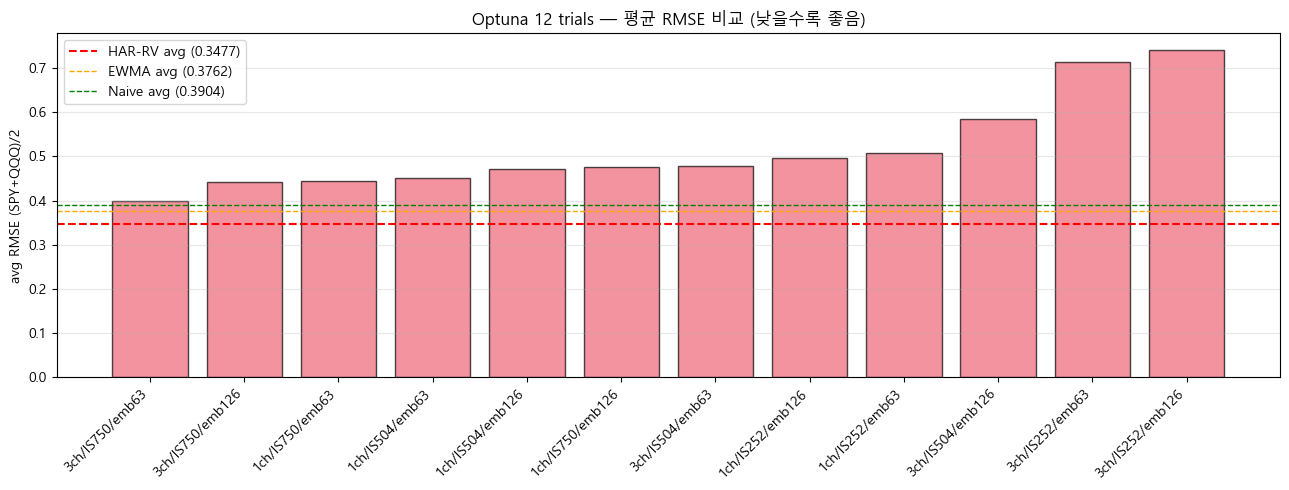

In [7]:
import matplotlib.pyplot as plt

# §7.A. Trial 별 평균 RMSE bar chart
fig, ax = plt.subplots(figsize=(13, 5))
df_sorted = df_trials.sort_values('avg_rmse').reset_index(drop=True)
labels = [
    f"{r['input_channels']}/IS{r['is_len']}/emb{r['embargo']}"
    for _, r in df_sorted.iterrows()
]
colors = ['#4477AA' if r['avg_rmse'] < BASELINE_RMSE['har']['avg'] else '#EE6677'
          for _, r in df_sorted.iterrows()]
ax.bar(range(len(df_sorted)), df_sorted['avg_rmse'], color=colors, alpha=0.7, edgecolor='black')
ax.axhline(BASELINE_RMSE['har']['avg'], color='red', lw=1.5, ls='--',
           label=f'HAR-RV avg ({BASELINE_RMSE["har"]["avg"]:.4f})')
ax.axhline(BASELINE_RMSE['ewma']['avg'], color='orange', lw=1.0, ls='--',
           label=f'EWMA avg ({BASELINE_RMSE["ewma"]["avg"]:.4f})')
ax.axhline(BASELINE_RMSE['naive']['avg'], color='green', lw=1.0, ls='--',
           label=f'Naive avg ({BASELINE_RMSE["naive"]["avg"]:.4f})')
ax.set_xticks(range(len(df_sorted)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('avg RMSE (SPY+QQQ)/2')
ax.set_title('Optuna 12 trials — 평균 RMSE 비교 (낮을수록 좋음)')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


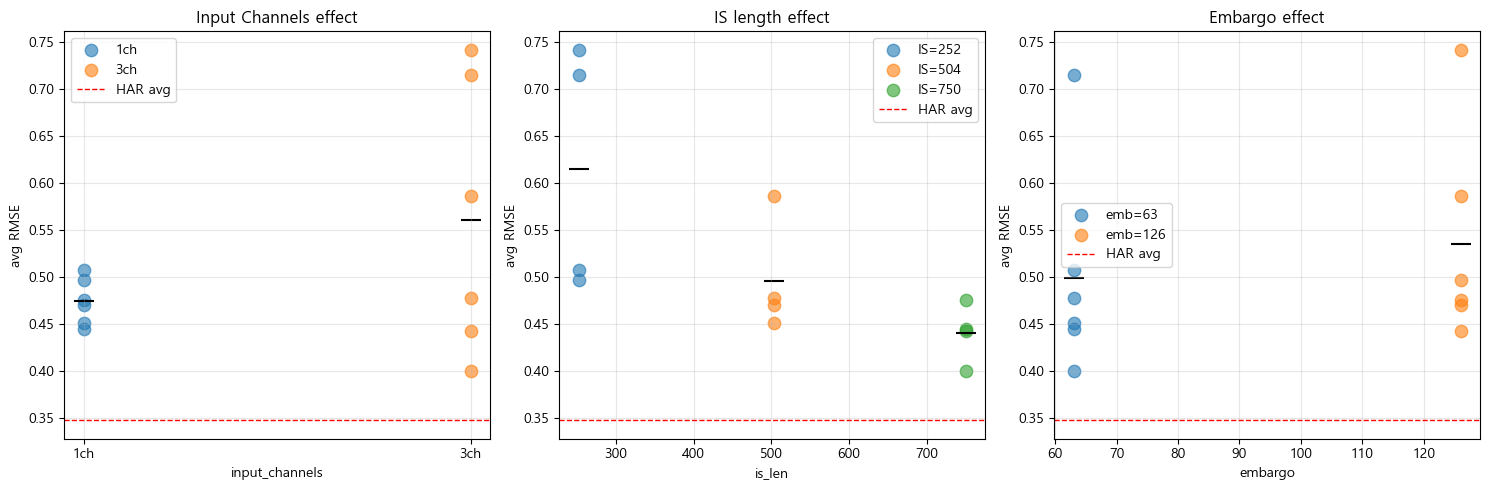

In [8]:
# §7.B. 변수별 marginal effect

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# input_channels 효과
ax = axes[0]
for ch in ['1ch', '3ch']:
    sub = df_trials[df_trials['input_channels'] == ch]
    ax.scatter([ch] * len(sub), sub['avg_rmse'], s=80, alpha=0.6, label=ch)
    ax.scatter([ch], [sub['avg_rmse'].mean()], s=200, marker='_', color='black', label=None)
ax.axhline(BASELINE_RMSE['har']['avg'], color='red', lw=1.0, ls='--', label='HAR avg')
ax.set_title('Input Channels effect')
ax.set_ylabel('avg RMSE')
ax.set_xlabel('input_channels')
ax.legend()
ax.grid(alpha=0.3)

# is_len 효과
ax = axes[1]
for is_l in [252, 504, 750]:
    sub = df_trials[df_trials['is_len'] == is_l]
    ax.scatter([is_l] * len(sub), sub['avg_rmse'], s=80, alpha=0.6, label=f'IS={is_l}')
    ax.scatter([is_l], [sub['avg_rmse'].mean()], s=200, marker='_', color='black')
ax.axhline(BASELINE_RMSE['har']['avg'], color='red', lw=1.0, ls='--', label='HAR avg')
ax.set_title('IS length effect')
ax.set_ylabel('avg RMSE')
ax.set_xlabel('is_len')
ax.legend()
ax.grid(alpha=0.3)

# embargo 효과
ax = axes[2]
for emb in [63, 126]:
    sub = df_trials[df_trials['embargo'] == emb]
    ax.scatter([emb] * len(sub), sub['avg_rmse'], s=80, alpha=0.6, label=f'emb={emb}')
    ax.scatter([emb], [sub['avg_rmse'].mean()], s=200, marker='_', color='black')
ax.axhline(BASELINE_RMSE['har']['avg'], color='red', lw=1.0, ls='--', label='HAR avg')
ax.set_title('Embargo effect')
ax.set_ylabel('avg RMSE')
ax.set_xlabel('embargo')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## §8. 결론 + `lstm_optuna_summary.md` 자동 생성

### 출력
1. 최적 조합 metrics 저장
2. `lstm_optuna_summary.md` 자동 생성 — 사용자·팀 공유용


In [9]:
# 최적 조합 metrics 저장
best_metrics = {
    'best_params': study.best_params,
    'best_avg_rmse': float(study.best_value),
    'best_trial': int(df_trials.iloc[0]['trial']),
    'all_trials': trial_records,
    'baseline_rmse': BASELINE_RMSE,
    'gate1_pass': bool(study.best_value < BASELINE_RMSE['har']['avg']),
    'hyperparams_fixed': {
        'hidden_size': HIDDEN, 'dropout': DROPOUT, 'lr': LR,
        'weight_decay': WEIGHT_DECAY, 'max_epochs': MAX_EPOCHS,
        'patience': PATIENCE, 'batch_size': BATCH_SIZE, 'seed': SEED,
    },
    'analysis_period': [ANALYSIS_START, ANALYSIS_END],
    'n_valid': N_VALID,
}
metrics_path = OPTUNA_DIR / 'best_metrics.json'
with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(best_metrics, f, ensure_ascii=False, indent=2)
print(f'저장: {metrics_path}')


# Summary markdown 자동 생성
summary_path = OPTUNA_DIR / 'lstm_optuna_summary.md'
lines = []
lines.append('# Phase 1.5 v3 — Optuna GridSearch 결과 요약')
lines.append('')
lines.append(f'> 분석 기간: {ANALYSIS_START} ~ {ANALYSIS_END}')
lines.append(f'> Search Space: 12 unique 조합 (input_channels × is_len × embargo)')
lines.append(f'> 고정: hidden=32, dropout=0.3, lr=1e-3 (v1 동일)')
lines.append(f'> 평가: (SPY + QQQ) RMSE 평균')
lines.append('')
lines.append('## 1. Best 조합')
lines.append('')
lines.append(f'- **input_channels**: `{study.best_params["input_channels"]}`')
lines.append(f'- **is_len**: `{study.best_params["is_len"]}`')
lines.append(f'- **embargo**: `{study.best_params["embargo"]}`')
lines.append(f'- **best avg RMSE**: `{study.best_value:.4f}`')
lines.append('')
lines.append('## 2. 12 Trials 전체 결과 (avg_rmse 오름차순)')
lines.append('')
lines.append('| rank | input | IS | emb | n_folds | SPY RMSE | QQQ RMSE | 평균 RMSE | vs HAR |')
lines.append('|---|---|---|---|---|---|---|---|---|')
for i, row in df_trials.iterrows():
    diff_har = row['avg_rmse'] - BASELINE_RMSE['har']['avg']
    sign = '+' if diff_har >= 0 else ''
    lines.append(
        f'| {i+1} | {row["input_channels"]} | {row["is_len"]} | {row["embargo"]} | '
        f'{row["n_folds"]} | {row["spy_rmse"]:.4f}±{row["spy_rmse_std"]:.3f} | '
        f'{row["qqq_rmse"]:.4f}±{row["qqq_rmse_std"]:.3f} | '
        f'{row["avg_rmse"]:.4f} | {sign}{diff_har:.4f} |'
    )
lines.append('')
lines.append('## 3. 베이스라인 비교')
lines.append('')
lines.append('| 모델 | 평균 RMSE |')
lines.append('|---|---|')
lines.append(f'| **Optuna best LSTM** | **{study.best_value:.4f}** |')
lines.append(f'| HAR-RV | {BASELINE_RMSE["har"]["avg"]:.4f} |')
lines.append(f'| EWMA | {BASELINE_RMSE["ewma"]["avg"]:.4f} |')
lines.append(f'| Naive | {BASELINE_RMSE["naive"]["avg"]:.4f} |')
lines.append(f'| Train-Mean | {BASELINE_RMSE["train_mean"]["avg"]:.4f} |')
lines.append('')
lines.append('## 4. 관문 1 재판정')
lines.append('')
lines.append(f'- 조건: best LSTM avg RMSE < HAR 평균 RMSE')
lines.append(f'- best: {study.best_value:.4f}')
lines.append(f'- HAR : {BASELINE_RMSE["har"]["avg"]:.4f}')
gate1 = study.best_value < BASELINE_RMSE['har']['avg']
lines.append(f'- **결과: {"PASS (LSTM 우위)" if gate1 else "FAIL (HAR 우위)"}**')
lines.append('')
lines.append('## 5. 핵심 발견 — 가설 검증 결과')
lines.append('')
# input_channels 효과
ic_avg = df_trials.groupby('input_channels')['avg_rmse'].mean()
better_ic = ic_avg.idxmin()
lines.append(f'- **가설 (a) 변수 부족**: `{better_ic}` 가 평균 RMSE 더 낮음 '
             f'(1ch={ic_avg.get("1ch", float("nan")):.4f}, 3ch={ic_avg.get("3ch", float("nan")):.4f})')
# is_len 효과
is_avg = df_trials.groupby('is_len')['avg_rmse'].mean()
best_is = is_avg.idxmin()
lines.append(f'- **가설 (a)+(c) 샘플·체제**: IS={best_is} 가 최적 '
             f'(252={is_avg.get(252, float("nan")):.4f}, '
             f'504={is_avg.get(504, float("nan")):.4f}, '
             f'750={is_avg.get(750, float("nan")):.4f})')
# embargo 효과
emb_avg = df_trials.groupby('embargo')['avg_rmse'].mean()
best_emb = emb_avg.idxmin()
lines.append(f'- **가설 (b) Long-memory**: embargo={best_emb} 가 최적 '
             f'(63={emb_avg.get(63, float("nan")):.4f}, 126={emb_avg.get(126, float("nan")):.4f})')
lines.append('')
lines.append('## 6. 결론')
lines.append('')
if gate1:
    lines.append('**관문 1 PASS** — Optuna best 조합이 HAR-RV 능가.')
    lines.append('Phase 1.5 결론 갱신 필요.')
else:
    lines.append('**관문 1 FAIL** — best 조합도 HAR-RV 능가 못 함.')
    lines.append('Phase 1.5 의 "LSTM 부적합" 결론 강화.')
lines.append('')

with open(summary_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines))
print(f'저장: {summary_path}')

print()
print('=' * 80)
print('Phase 1.5 v3 — Optuna GridSearch 완료')
print('=' * 80)
print(f'best params : {study.best_params}')
print(f'best avg RMSE: {study.best_value:.4f}')
print(f'관문 1 (vs HAR {BASELINE_RMSE["har"]["avg"]:.4f}): '
      f'{"PASS" if gate1 else "FAIL"}')
print()
print('산출물:')
print(f'  {csv_path.relative_to(BASE_DIR)}')
print(f'  {metrics_path.relative_to(BASE_DIR)}')
print(f'  {summary_path.relative_to(BASE_DIR)}')


저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_optuna\best_metrics.json
저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility\results\lstm_optuna\lstm_optuna_summary.md

Phase 1.5 v3 — Optuna GridSearch 완료
best params : {'input_channels': '3ch', 'is_len': 750, 'embargo': 63}
best avg RMSE: 0.4001
관문 1 (vs HAR 0.3477): FAIL

산출물:
  results\lstm_optuna\all_trials.csv
  results\lstm_optuna\best_metrics.json
  results\lstm_optuna\lstm_optuna_summary.md
